In [1]:
# Import the required packages/libraries
import pandas as pd 
import numpy as np                    
import seaborn as sns                 
import matplotlib.pyplot as plt       
%matplotlib inline 
import warnings 

In [2]:
# Read Data
# Data Downloaded from https://archive.ics.uci.edu/dataset/222/bank+marketing
bank_data=pd.read_csv("../data/bank-full.csv", sep=';') 
bank_data.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [3]:
# Check number of rows and columns - 16 plus target attribute
bank_data.shape

(45211, 17)

In [4]:
# Check for unique data values
print(bank_data['job'].unique())
print(bank_data['marital'].unique())
print(bank_data['education'].unique())
print(bank_data['default'].unique())
print(bank_data['housing'].unique())
print(bank_data['loan'].unique())
print(bank_data['contact'].unique())
print(bank_data['poutcome'].unique())
print(bank_data['y'].unique())


['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
['married' 'single' 'divorced']
['tertiary' 'secondary' 'unknown' 'primary']
['no' 'yes']
['yes' 'no']
['no' 'yes']
['unknown' 'cellular' 'telephone']
['unknown' 'failure' 'other' 'success']
['no' 'yes']


In [5]:
# Univariate Analysis - explore individual attribute
# Set the color coding for the visualizations to be plotted
import matplotlib

cmap = matplotlib.colormaps['jet']
cmap1 = matplotlib.colormaps['Spectral']


In [6]:
# Explore Target Variable - whether the client subscribed a term deposit
df = bank_data.copy()
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

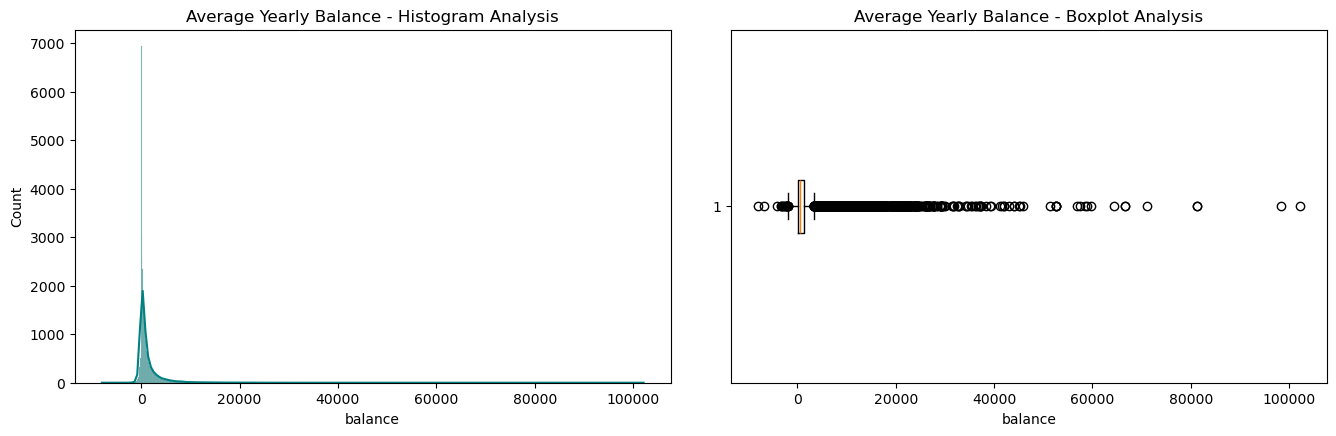

In [7]:
# Use raw dataset with numeric column 'balance'
df = bank_data.dropna(subset=['balance']).copy()

plt.figure(figsize=(14, 5))

# Histogram or KDE for distribution
plt.subplot(1, 2, 1)
sns.histplot(df['balance'], kde=True, color="teal")
plt.title("Average Yearly Balance - Histogram Analysis")
plt.xlabel("balance")

# Box Plot
plt.subplot(1, 2, 2)
plt.boxplot(df['balance'], vert=False)
plt.title("Average Yearly Balance - Boxplot Analysis")
plt.xlabel("balance")

plt.tight_layout(pad=3)
plt.show()

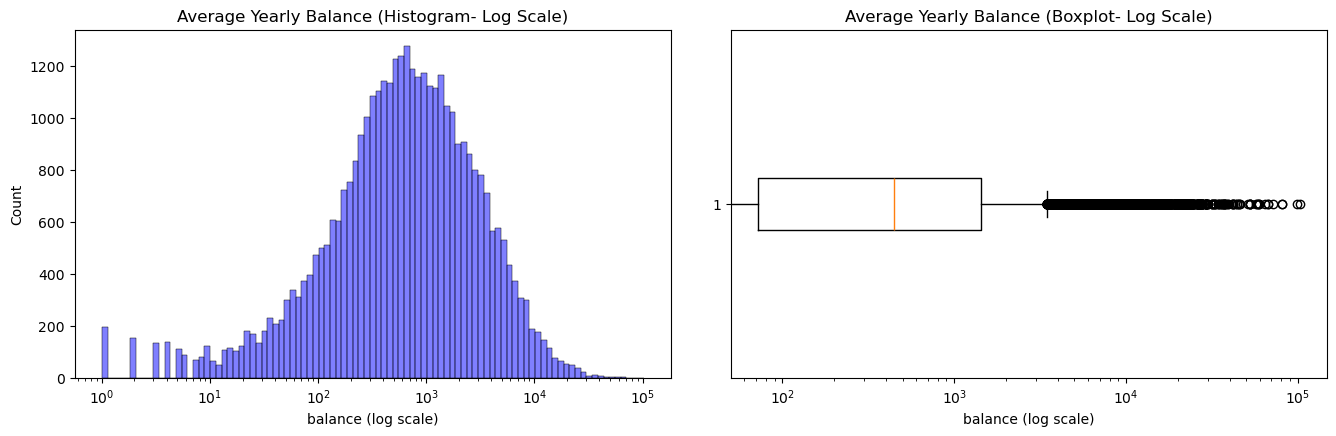

In [8]:
# As data is heavily skewed, having outliers, lets show the distribution using log scale
plt.figure(figsize=(14, 5))

# Histogram or KDE for distribution
plt.subplot(1, 2, 1)
sns.histplot(df['balance'], kde=True, color="blue", log_scale=True)
plt.title("Average Yearly Balance (Histogram- Log Scale)")
plt.xlabel("balance (log scale)")

# Box Plot
plt.subplot(1, 2, 2)
plt.boxplot(df['balance'], vert=False)
plt.xscale('log')
plt.title("Average Yearly Balance (Boxplot- Log Scale)")
plt.xlabel("balance (log scale)")

plt.tight_layout(pad=3)
plt.show()

In [9]:
# Feature Engineering
# Checking for missing values - 
# Methods to fill the missing values:

    #For numerical variables: imputation using mean or median
    #For categorical variables: imputation using mode

bank_data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [10]:
# No missing value
## One way to remove the skewness is by doing the log transformation. With log transformation, 
# it does not affect the smaller values much, but reduces the larger values, 
# so it gives a distribution similar to normal distributionLog transformation

#Check for zero or negative balance
bank_data['balance'].describe()
(bank_data['balance'] <= 0).sum()





np.int64(7280)

In [11]:
# As balance contains zero/negative values, applying direct logarithmic transformation results 
# in undefined values. Therefore a log(1+x) transformation can be used to safely handle zero balances 
# while reducing skewness
min_balance = bank_data['balance'].min()
bank_data['balance_log'] = np.log1p(bank_data['balance'] - min_balance + 1)

bank_data.head(10)



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,balance_log
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,9.226607
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,8.993427
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,8.990068
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,9.161885
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,8.989943
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no,9.018211
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no,9.044050
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no,8.990068
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no,9.004791
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no,9.061144


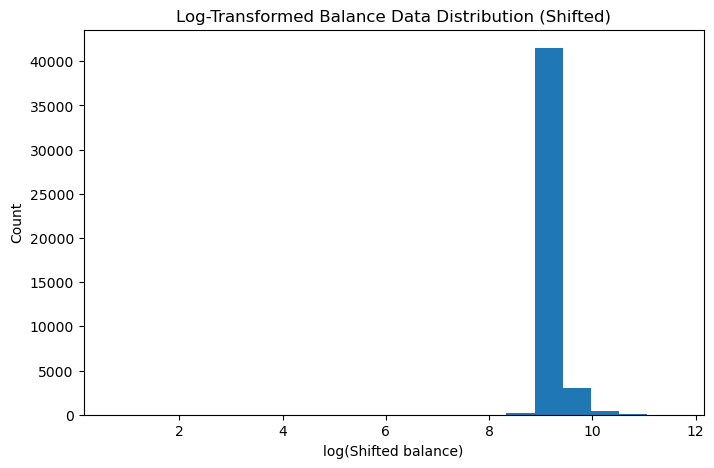

In [12]:
# Histogram of log-transformed balance
plt.figure(figsize=(8,5))
bank_data['balance_log'].hist(bins=20, grid=False)
plt.title("Log-Transformed Balance Data Distribution (Shifted)")
plt.xlabel("log(Shifted balance)")
plt.ylabel("Count")
plt.show()

In [13]:
# Datatype conversion

bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          45211 non-null  int64  
 1   job          45211 non-null  object 
 2   marital      45211 non-null  object 
 3   education    45211 non-null  object 
 4   default      45211 non-null  object 
 5   balance      45211 non-null  int64  
 6   housing      45211 non-null  object 
 7   loan         45211 non-null  object 
 8   contact      45211 non-null  object 
 9   day          45211 non-null  int64  
 10  month        45211 non-null  object 
 11  duration     45211 non-null  int64  
 12  campaign     45211 non-null  int64  
 13  pdays        45211 non-null  int64  
 14  previous     45211 non-null  int64  
 15  poutcome     45211 non-null  object 
 16  y            45211 non-null  object 
 17  balance_log  45211 non-null  float64
dtypes: float64(1), int64(7), object(10)
memory usa

In [14]:
# Change to categorical
bank_data = bank_data.astype({"job":'category', "marital":'category',  "education":'category', "contact":'category', "month":'category', "poutcome":'category'})

In [15]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          45211 non-null  int64   
 1   job          45211 non-null  category
 2   marital      45211 non-null  category
 3   education    45211 non-null  category
 4   default      45211 non-null  object  
 5   balance      45211 non-null  int64   
 6   housing      45211 non-null  object  
 7   loan         45211 non-null  object  
 8   contact      45211 non-null  category
 9   day          45211 non-null  int64   
 10  month        45211 non-null  category
 11  duration     45211 non-null  int64   
 12  campaign     45211 non-null  int64   
 13  pdays        45211 non-null  int64   
 14  previous     45211 non-null  int64   
 15  poutcome     45211 non-null  category
 16  y            45211 non-null  object  
 17  balance_log  45211 non-null  float64 
dtypes: category(6), float64(1)

In [16]:
# The variables month and day describe campaign timing and execution details rather than 
# customer attributes.
# Therefore, these variables can be removed without affecting the model’s quality.

bank_data = bank_data.drop(['month'], axis=1, errors='ignore')
bank_data = bank_data.drop(['day'], axis=1, errors='ignore')

# Attribute "duration" highly affects the output target (e.g., if duration=0 then y='no'). 
# Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, 
# this input should only be included for benchmark purposes and discarded if the intention is to have a realistic predictive model.

bank_data = bank_data.drop(['duration'], axis=1, errors='ignore')

In [17]:
bank_data.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,campaign,pdays,previous,poutcome,y,balance_log
0,58,management,married,tertiary,no,2143,yes,no,unknown,1,-1,0,unknown,no,9.226607
1,44,technician,single,secondary,no,29,yes,no,unknown,1,-1,0,unknown,no,8.993427
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,1,-1,0,unknown,no,8.990068
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,1,-1,0,unknown,no,9.161885
4,33,unknown,single,unknown,no,1,no,no,unknown,1,-1,0,unknown,no,8.989943
5,35,management,married,tertiary,no,231,yes,no,unknown,1,-1,0,unknown,no,9.018211
6,28,management,single,tertiary,no,447,yes,yes,unknown,1,-1,0,unknown,no,9.044050
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,1,-1,0,unknown,no,8.990068
8,58,retired,married,primary,no,121,yes,no,unknown,1,-1,0,unknown,no,9.004791
9,43,technician,single,secondary,no,593,yes,no,unknown,1,-1,0,unknown,no,9.061144


In [18]:
bank_data.isnull().sum()

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
balance_log    0
dtype: int64

In [19]:
# Model Building

# LOGICTIC REGRESSION


In [20]:
#X is set of independant variables
X = bank_data.drop('y',axis = 1) 

#y is target variable
Y = bank_data.y

In [21]:
X.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'campaign', 'pdays', 'previous', 'poutcome',
       'balance_log'],
      dtype='object')

In [22]:
# The dataframe has dummy variables, but those also needs to be converted into dummies.
X = pd.get_dummies(X) 
bank_data = pd.get_dummies(bank_data)

In [23]:
display(X)

,age,balance,campaign,pdays,previous,balance_log,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,housing_yes,loan_no,loan_yes,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,1,-1,0,9.226607,False,False,False,False,...,True,True,False,False,False,True,False,False,False,True
1,44,29,1,-1,0,8.993427,False,False,False,False,...,True,True,False,False,False,True,False,False,False,True
2,33,2,1,-1,0,8.990068,False,False,True,False,...,True,False,True,False,False,True,False,False,False,True
3,47,1506,1,-1,0,9.161885,False,True,False,False,...,True,True,False,False,False,True,False,False,False,True
4,33,1,1,-1,0,8.989943,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,3,-1,0,9.087721,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
45207,71,1729,2,-1,0,9.185023,False,False,False,False,...,False,True,False,True,False,False,False,False,False,True
45208,72,5715,5,184,3,9.527775,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
45209,57,668,4,-1,0,9.069813,False,True,False,False,...,False,True,False,False,True,False,False,False,False,True


In [24]:
bank_data.isnull().sum()

age                    0
balance                0
campaign               0
pdays                  0
previous               0
balance_log            0
job_admin.             0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
job_technician         0
job_unemployed         0
job_unknown            0
marital_divorced       0
marital_married        0
marital_single         0
education_primary      0
education_secondary    0
education_tertiary     0
education_unknown      0
default_no             0
default_yes            0
housing_no             0
housing_yes            0
loan_no                0
loan_yes               0
contact_cellular       0
contact_telephone      0
contact_unknown        0
poutcome_failure       0
poutcome_other         0
poutcome_success       0
poutcome_unknown       0
y_no                   0
y_yes                  0


In [25]:
# Target
Y = bank_data['y_yes']

# Features (drop both dummy target columns)
X = bank_data.drop(['y_yes', 'y_no'], axis=1)

In [26]:
X.columns

Index(['age', 'balance', 'campaign', 'pdays', 'previous', 'balance_log',
       'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'default_no', 'default_yes', 'housing_no',
       'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'poutcome_failure',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')

In [27]:
# Use the train_test_split function from sklearn to divide dataset
!pip install scikit-learn

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size =0.3)

In [29]:
# SCALING
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [30]:
X_train =scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
# Model Building
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef

In [32]:
model_LR = LogisticRegression(random_state=100) 
model_LR.fit(X_train, Y_train)

LogisticRegression(random_state=100)

In [33]:
model_LR.classes_

array([False,  True])

In [34]:
model_LR.coef_

array([[ 1.00738227e-01, -4.88120286e-02, -5.00009825e+00,
         2.01983933e-01,  1.00614207e+00,  1.85140318e+00,
        -4.72620984e-04, -1.14860521e-01, -2.10184384e-01,
        -3.93429844e-01, -1.50374343e-01,  4.70098626e-01,
        -2.41344343e-01, -1.87907108e-01,  3.90431448e-01,
        -1.98239768e-01,  2.08331314e-01, -2.07381831e-01,
        -1.72578457e-01, -4.17022701e-01, -4.57322171e-02,
        -3.44764443e-01, -2.06614371e-01,  1.65816956e-03,
        -8.56127311e-02, -2.18589678e-01, -4.16743697e-01,
        -4.93639316e-03, -6.30396982e-01, -9.95742715e-02,
        -5.35759104e-01,  1.63301528e-01, -1.46625972e-02,
        -7.83972306e-01, -8.02588593e-01, -4.52199527e-01,
         1.47408705e+00, -8.54632301e-01]])

In [35]:
model_LR.intercept_

array([-0.91853443])

In [36]:
predicted = model_LR.predict(X_test)

In [37]:
actual = Y_test

In [38]:
accuracy_score(actual,predicted)

0.8911825420230021

In [39]:
y_pred_probability = model_LR.predict_proba(X_test)[:, 1]

# Metrics
lr_auc = roc_auc_score(Y_test, y_pred_probability)
lr_precision = precision_score(Y_test, predicted)
lr_recall = recall_score(Y_test, predicted)
lr_f1 = f1_score(Y_test, predicted)
lr_mcc = matthews_corrcoef(Y_test, predicted)
lr_acc=accuracy_score(actual,predicted)

print (" ***** LOGICTIC REGRESSION MODEL **** ")
print("1. Accuracy  :", lr_acc)
print("2. AUC Score :", lr_auc)
print("3. Precision :", lr_precision)
print("4. Recall    :", lr_recall)
print("5. F1 Score  :", lr_f1)
print("6. MCC       :", lr_mcc)

 ***** LOGICTIC REGRESSION MODEL **** 
1. Accuracy  : 0.8911825420230021
2. AUC Score : 0.7429775773352307
3. Precision : 0.6546762589928058
4. Recall    : 0.17009345794392525
5. F1 Score  : 0.27002967359050445
6. MCC       : 0.2957361809718874


In [40]:
# FEATURE IMPORTANCE
#import pandas as pd
#import numpy as np

#X_enc = pd.get_dummies(bank_data, drop_first=True)
ft_names = X.columns

# Logistic Regression coefficients (for binary classification it's shape: (1, n_features))
coefficients = model_LR.coef_[0]

# Match each coefficient with its feature name
ft_importance = pd.DataFrame({
    'Feature': ft_names,
    'Coefficient': coefficients
})

# Sort by absolute importance (descending)
ft_importance['Abs_Coeff'] = ft_importance['Coefficient'].abs()
ft_importance = ft_importance.sort_values(by='Abs_Coeff', ascending=False)

ft_importance

,Feature,Coefficient,Abs_Coeff
2,campaign,-5.000098,5.000098
5,balance_log,1.851403,1.851403
36,poutcome_success,1.474087,1.474087
4,previous,1.006142,1.006142
37,poutcome_unknown,-0.854632,0.854632
34,poutcome_failure,-0.802589,0.802589
33,contact_unknown,-0.783972,0.783972
28,housing_yes,-0.630397,0.630397
30,loan_yes,-0.535759,0.535759
11,job_retired,0.470099,0.470099


In [41]:
# Using kFoldStratification
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X1 = X.to_numpy()
Y1 = Y.to_numpy()

In [42]:
number_of_splits = 5 
iteration = 1 
sum_of_accuracies = 0 
skf = StratifiedKFold(n_splits=number_of_splits, shuffle=True, random_state=100)
for train_index, test_index in skf.split(X1, Y1):
    X_train, X_test = X1[train_index], X1[test_index]
    Y_train, Y_test = Y1[train_index], Y1[test_index]
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, solver="lbfgs", random_state=1))    
    model.fit(X_train, Y_train) 
    pred_test = model.predict(X_test)     
    score = accuracy_score(Y_test,pred_test) 
    sum_of_accuracies = sum_of_accuracies + score
    print(' Iteration : ', iteration, '    Accuracy score : ',score)     
    iteration = iteration + 1
   
print('\nAverage Accuracy : ', sum_of_accuracies / number_of_splits)  

 Iteration :  1     Accuracy score :  0.8928452947030853
 Iteration :  2     Accuracy score :  0.8918380889183809
 Iteration :  3     Accuracy score :  0.8921698739216988
 Iteration :  4     Accuracy score :  0.8953771289537713
 Iteration :  5     Accuracy score :  0.8925016589250165

Average Accuracy :  0.8929464090843904


In [43]:
# Average accuracy obtained after 5 fold validation is around 90.02%.

In [44]:
# DECISION TREE CLASSIFIER

In [45]:
!pip install pydot 

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
#Y = bank_data['y_yes']
#X = bank_data.drop(['y_yes', 'y_no'], axis=1)

#Train–test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


# Build & train Decision Tree

dt_model = DecisionTreeClassifier(
    criterion='entropy',    
    max_depth=4,    
    random_state=42
)

dt_model.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

Decision Tree Classifier – Train Accuracy: 0.8935
Decision Tree Classifier – Test Accuracy : 0.8928

Classification Result:

                precision    recall  f1-score   support

Not Subscribed       0.90      0.99      0.94      7985
    Subscribed       0.64      0.19      0.30      1058

      accuracy                           0.89      9043
     macro avg       0.77      0.59      0.62      9043
  weighted avg       0.87      0.89      0.87      9043



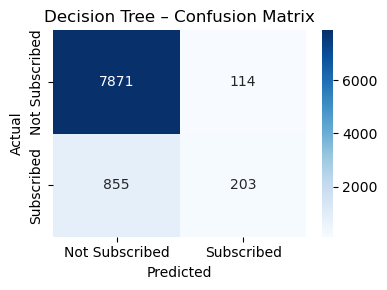

In [48]:
from sklearn.metrics import confusion_matrix, classification_report
# Predictions
Y_pred = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Classifier – Train Accuracy:", round(dt_model.score(X_train, Y_train), 4))
print("Decision Tree Classifier – Test Accuracy :", round(accuracy_score(Y_test, Y_pred), 4))

# Classification result
print("\nClassification Result:\n")
print(classification_report(Y_test, Y_pred, target_names=["Not Subscribed", "Subscribed"]))

# Confusion matrix heatmap
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Subscribed','Subscribed'],
            yticklabels=['Not Subscribed','Subscribed'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree – Confusion Matrix")
plt.tight_layout()
plt.show()



Feature Importances:
                 Feature  Importance
36     poutcome_success    0.590503
33      contact_unknown    0.190042
28          housing_yes    0.106484
0                   age    0.062536
3                 pdays    0.030269
19      marital_married    0.010879
5           balance_log    0.004793
2              campaign    0.004493
6            job_admin.    0.000000
7       job_blue-collar    0.000000
35       poutcome_other    0.000000
34     poutcome_failure    0.000000
4              previous    0.000000
32    contact_telephone    0.000000
31     contact_cellular    0.000000
30             loan_yes    0.000000
29              loan_no    0.000000
27           housing_no    0.000000
26          default_yes    0.000000
25           default_no    0.000000
24    education_unknown    0.000000
23   education_tertiary    0.000000
22  education_secondary    0.000000
21    education_primary    0.000000
20       marital_single    0.000000
1               balance    0.000000
18   

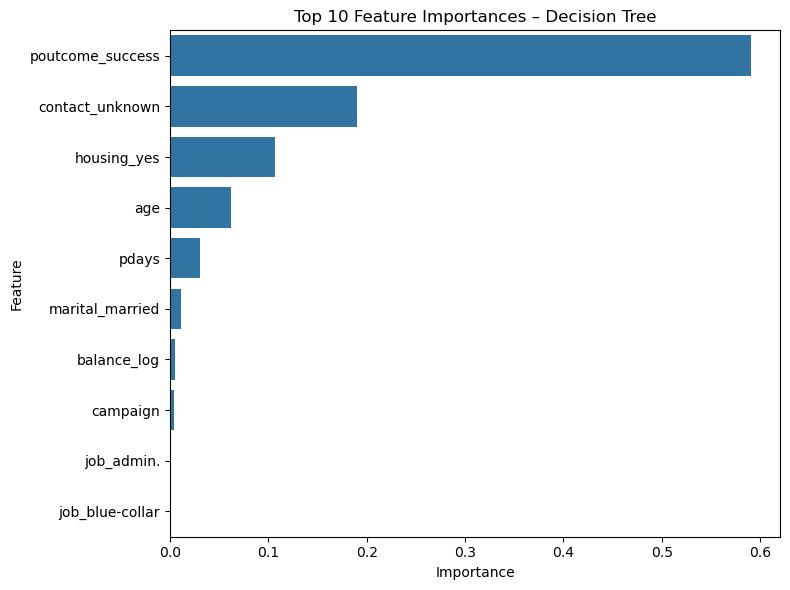

In [49]:
# Feature Importance

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:\n", feat_imp)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances – Decision Tree")
plt.tight_layout()
plt.show()

In [50]:
# Tree form
from sklearn.tree import plot_tree


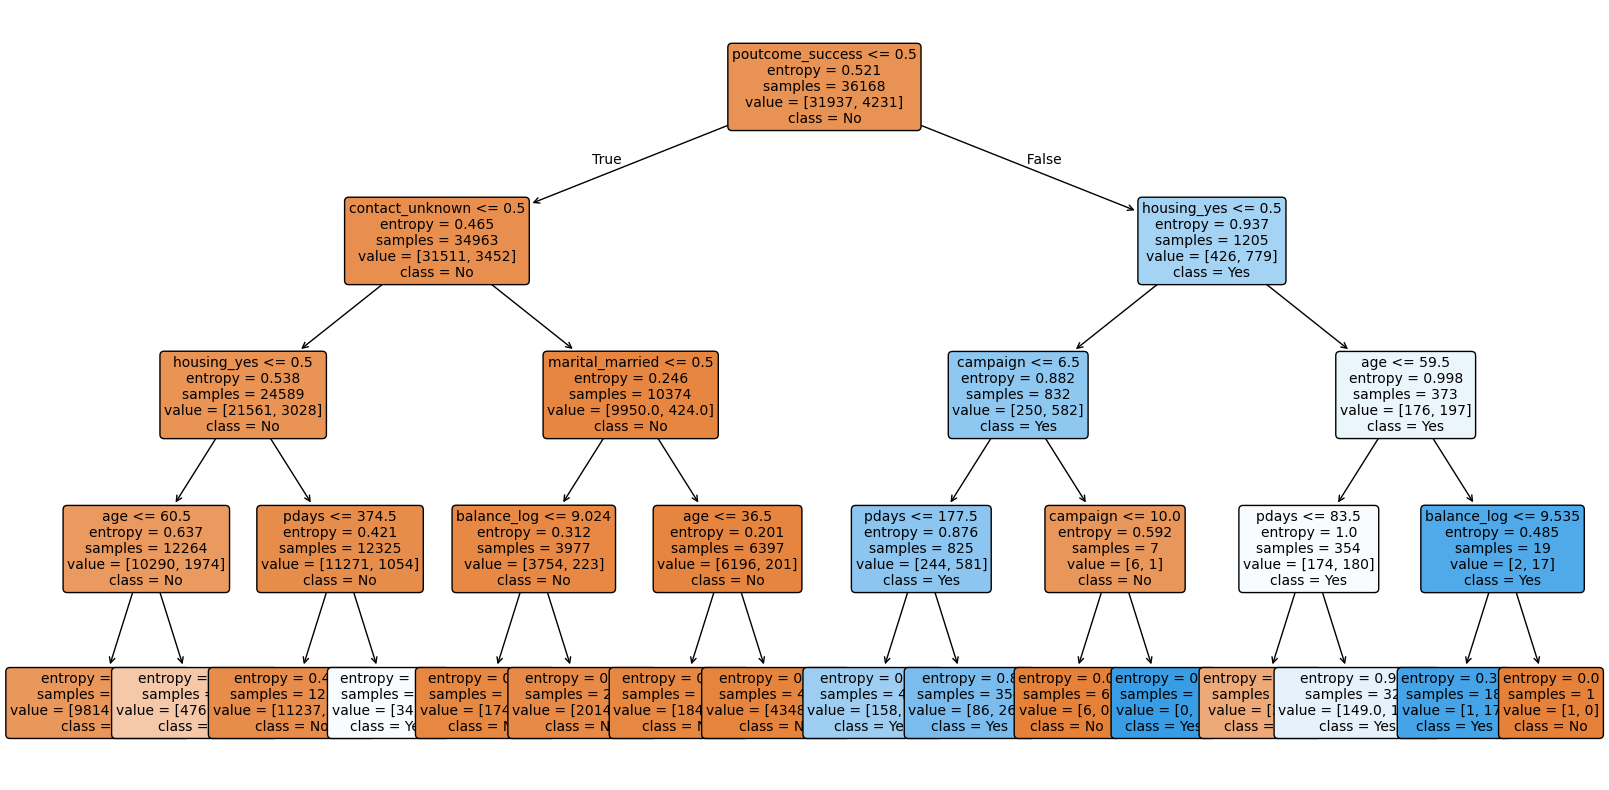

In [51]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [52]:
# Metrics calculation
# Class predictions
dt_pred = dt_model.predict(X_test)

# Predicted probabilities (for AUC)
dt_pred_proba = dt_model.predict_proba(X_test)[:, 1]

In [53]:
dt_accuracy = accuracy_score(Y_test, dt_pred)
dt_auc = roc_auc_score(Y_test, dt_pred_proba)
dt_precision = precision_score(Y_test, dt_pred)
dt_recall = recall_score(Y_test, dt_pred)
dt_f1 = f1_score(Y_test, dt_pred)
dt_mcc = matthews_corrcoef(Y_test, dt_pred)

In [54]:
print(" ***** DECISION TREE MODEL ***** ")
print("1. Accuracy :", dt_accuracy)
print("2. AUC Score :", dt_auc)
print("3. Precision :", dt_precision)
print("4. Recall :", dt_recall)
print("5. F1 Score :", dt_f1)
print("6. MCC :", dt_mcc)

 ***** DECISION TREE MODEL ***** 
1. Accuracy : 0.8928452947030853
2. AUC Score : 0.7157639027808521
3. Precision : 0.6403785488958991
4. Recall : 0.19187145557655955
5. F1 Score : 0.2952727272727273
6. MCC : 0.31036520516605476


In [55]:
# K-Nearest Neighbor Classifier
from sklearn.neighbors import KNeighborsClassifier

In [56]:
from sklearn.preprocessing import StandardScaler

# Scaling for distance-based models (KNN)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
# KNN Model
knn_model = KNeighborsClassifier(
    n_neighbors=5 
)
knn_model.fit(X_train_scaled, Y_train)


KNeighborsClassifier()

In [58]:
# Predictions
knn_pred = knn_model.predict(X_test_scaled)

# Probabilities (needed for AUC)
knn_pred_probability = knn_model.predict_proba(X_test_scaled)[:, 1]

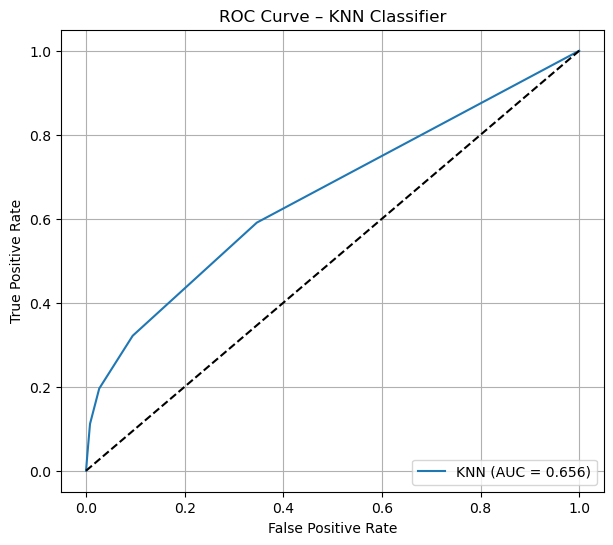

In [59]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, _ = roc_curve(Y_test, knn_pred_probability)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – KNN Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [60]:
knn_accuracy = accuracy_score(Y_test, knn_pred)
knn_auc = roc_auc_score(Y_test, knn_pred_probability)
knn_precision = precision_score(Y_test, knn_pred)
knn_recall = recall_score(Y_test, knn_pred)
knn_f1 = f1_score(Y_test, knn_pred)
knn_mcc = matthews_corrcoef(Y_test, knn_pred)

In [61]:
print(" ***** K-NEAREST NEIGHBOR MODEL ***** ")
print("1. Accuracy :", knn_accuracy)
print("2. AUC Score :", knn_auc)
print("3. Precision :", knn_precision)
print("4. Recall :", knn_recall)
print("5. F1 Score :", knn_f1)
print("6. MCC :", knn_mcc)

 ***** K-NEAREST NEIGHBOR MODEL ***** 
1. Accuracy : 0.8823399314386818
2. AUC Score : 0.6556182847565083
3. Precision : 0.4928571428571429
4. Recall : 0.1956521739130435
5. F1 Score : 0.28010825439783493
6. MCC : 0.2580800641581006


In [62]:
# Gaussian Naive Bayes (GNB)
from sklearn.naive_bayes import GaussianNB


In [63]:
gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, Y_train)
gnb_pred = gnb_model.predict(X_test_scaled)
gnb_pred_proba = gnb_model.predict_proba(X_test_scaled)[:, 1]

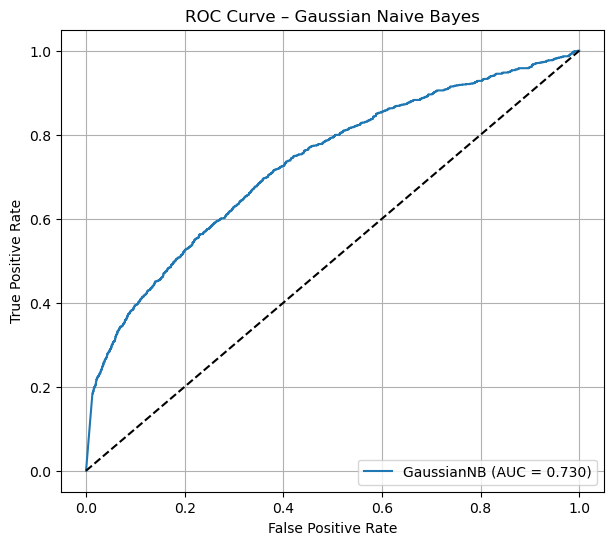

In [64]:
fpr, tpr, _ = roc_curve(Y_test, gnb_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'GaussianNB (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Gaussian Naive Bayes')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [65]:
gnb_accuracy = accuracy_score(Y_test, gnb_pred)
gnb_auc = roc_auc_score(Y_test, gnb_pred_proba)
gnb_precision = precision_score(Y_test, gnb_pred)
gnb_recall = recall_score(Y_test, gnb_pred)
gnb_f1 = f1_score(Y_test, gnb_pred)
gnb_mcc = matthews_corrcoef(Y_test, gnb_pred)

In [66]:
print(" ***** GAUSSIAN NAIVE BAYES MODEL ***** ")
print("1. Accuracy :", gnb_accuracy)
print("2. AUC Score :", gnb_auc)
print("3. Precision :", gnb_precision)
print("4. Recall :", gnb_recall)
print("5. F1 Score :", gnb_f1)
print("6. MCC :", gnb_mcc)

 ***** GAUSSIAN NAIVE BAYES MODEL ***** 
1. Accuracy : 0.7929890523056508
2. AUC Score : 0.7296402280741419
3. Precision : 0.27759562841530055
4. Recall : 0.48015122873345933
5. F1 Score : 0.3518005540166205
6. MCC : 0.2516765807231068


In [67]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

In [68]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [69]:
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

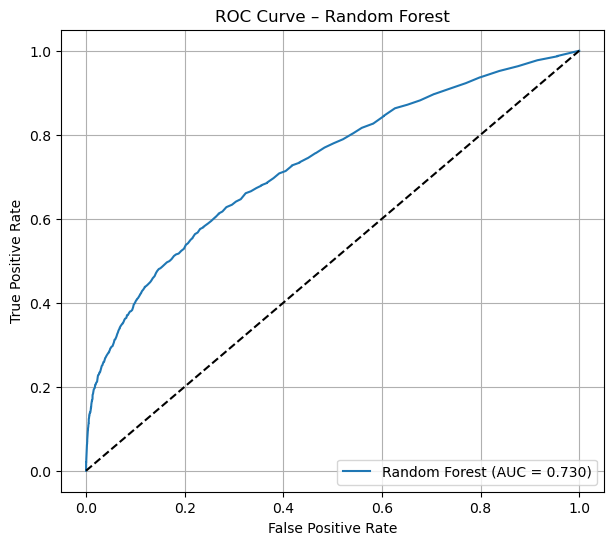

In [70]:
fpr, tpr, _ = roc_curve(Y_test, rf_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [71]:
rf_accuracy = accuracy_score(Y_test, rf_pred)
rf_auc = roc_auc_score(Y_test, rf_pred_proba)
rf_precision = precision_score(Y_test, rf_pred)
rf_recall = recall_score(Y_test, rf_pred)
rf_f1 = f1_score(Y_test, rf_pred)
rf_mcc = matthews_corrcoef(Y_test, rf_pred)

In [72]:
print(" ***** RANDOM FOREST MODEL ***** ")
print("1. Accuracy :", rf_accuracy)
print("2. AUC Score :", rf_auc)
print("3. Precision :", rf_precision)
print("4. Recall :", rf_recall)
print("5. F1 Score :", rf_f1)
print("6. MCC :", rf_mcc)

 ***** RANDOM FOREST MODEL ***** 
1. Accuracy : 0.8893066460245493
2. AUC Score : 0.7302170421146456
3. Precision : 0.5736434108527132
4. Recall : 0.20982986767485823
5. F1 Score : 0.30726643598615916
6. MCC : 0.30040665605866557


In [73]:
# XGBoost
#from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

In [74]:
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=500,
    random_state=42
)

hgb_model.fit(X_train, Y_train)

HistGradientBoostingClassifier(learning_rate=0.05, max_depth=6, max_iter=500,
                               random_state=42)

In [75]:
xgb_pred = hgb_model.predict(X_test)
xgb_pred_proba = hgb_model.predict_proba(X_test)[:, 1]

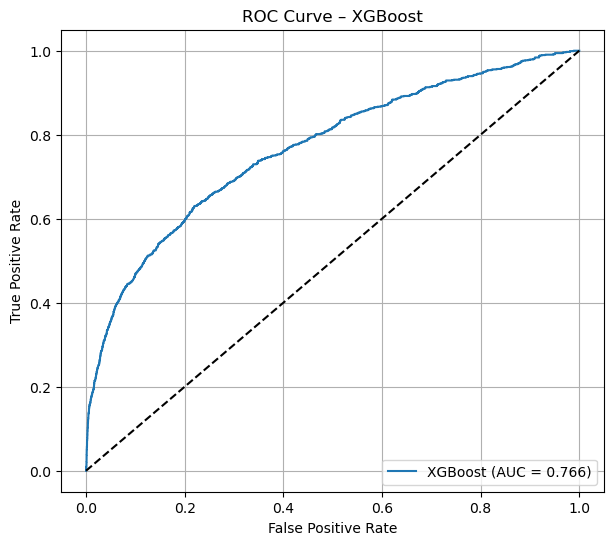

In [76]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(Y_test, xgb_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [77]:
hgb_accuracy = accuracy_score(Y_test, xgb_pred)
hgb_auc = roc_auc_score(Y_test, xgb_pred_proba)
hgb_precision = precision_score(Y_test, xgb_pred)
hgb_recall = recall_score(Y_test, xgb_pred)
hgb_f1 = f1_score(Y_test, xgb_pred)
hgb_mcc = matthews_corrcoef(Y_test, xgb_pred)

In [78]:
print(" ***** HIST GRADIENT BOOSTING MODEL (XGBOOST) ***** ")
print("1. Accuracy :", hgb_accuracy)
print("2. AUC Score :", hgb_auc)
print("3. Precision :", hgb_precision)
print("4. Recall :", hgb_recall)
print("5. F1 Score :", hgb_f1)
print("6. MCC :", hgb_mcc)

 ***** HIST GRADIENT BOOSTING MODEL (XGBOOST) ***** 
1. Accuracy : 0.8941722879575362
2. AUC Score : 0.7663308921619342
3. Precision : 0.6891385767790262
4. Recall : 0.17391304347826086
5. F1 Score : 0.27773584905660376
6. MCC : 0.3104869803381018


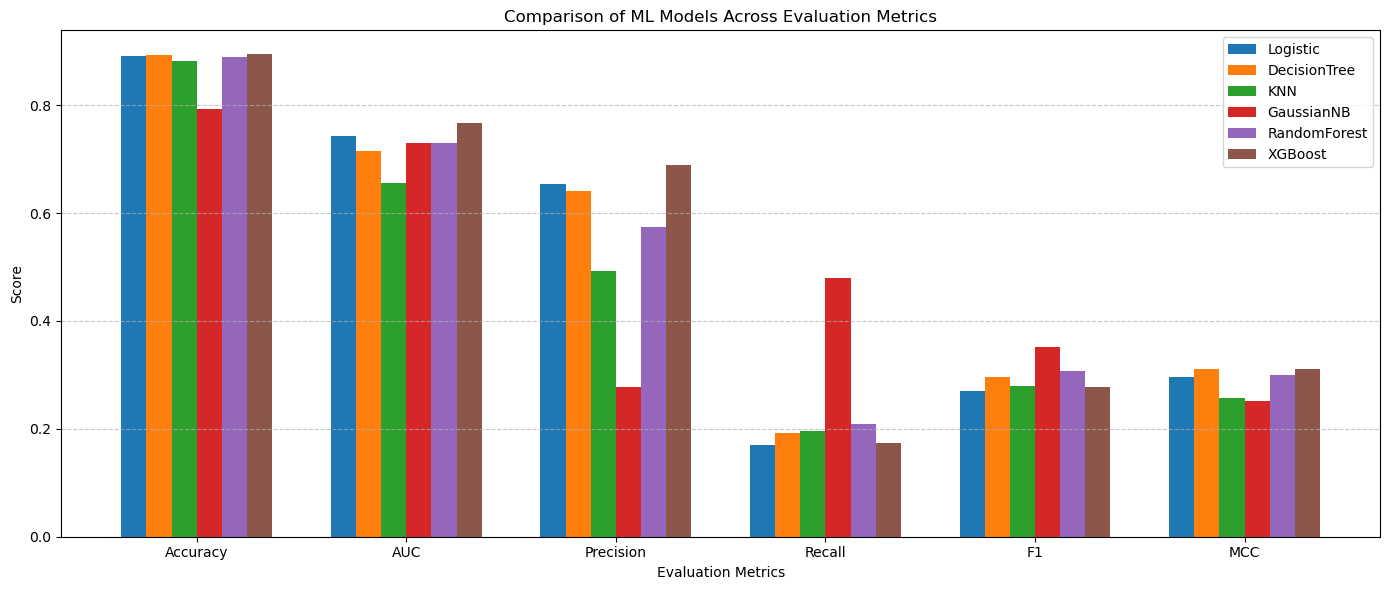

In [79]:
# Model Comparison

# Create results table from your existing variables

results = pd.DataFrame({
    "Logistic":     [lr_acc, lr_auc, lr_precision, lr_recall, lr_f1, lr_mcc],
    "DecisionTree":[dt_accuracy, dt_auc, dt_precision, dt_recall, dt_f1, dt_mcc],
    "KNN":          [knn_accuracy, knn_auc, knn_precision, knn_recall, knn_f1, knn_mcc],
    "GaussianNB":   [gnb_accuracy, gnb_auc, gnb_precision, gnb_recall, gnb_f1, gnb_mcc],
    "RandomForest":[rf_accuracy, rf_auc, rf_precision, rf_recall, rf_f1, rf_mcc],
    "XGBoost":      [hgb_accuracy, hgb_auc, hgb_precision, hgb_recall, hgb_f1, hgb_mcc]
},
index=["Accuracy","AUC","Precision","Recall","F1","MCC"]
)

# Plot grouped bar chart
metrics = ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]
models = results.columns.tolist()

x = np.arange(len(metrics))
width = 0.12

plt.figure(figsize=(14, 6))

for i, model in enumerate(models):
    plt.bar(x + i*width, results[model].values, width, label=model)


plt.xticks(x + width*(len(models)-1)/2, metrics)

plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")

plt.title("Comparison of ML Models Across Evaluation Metrics")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


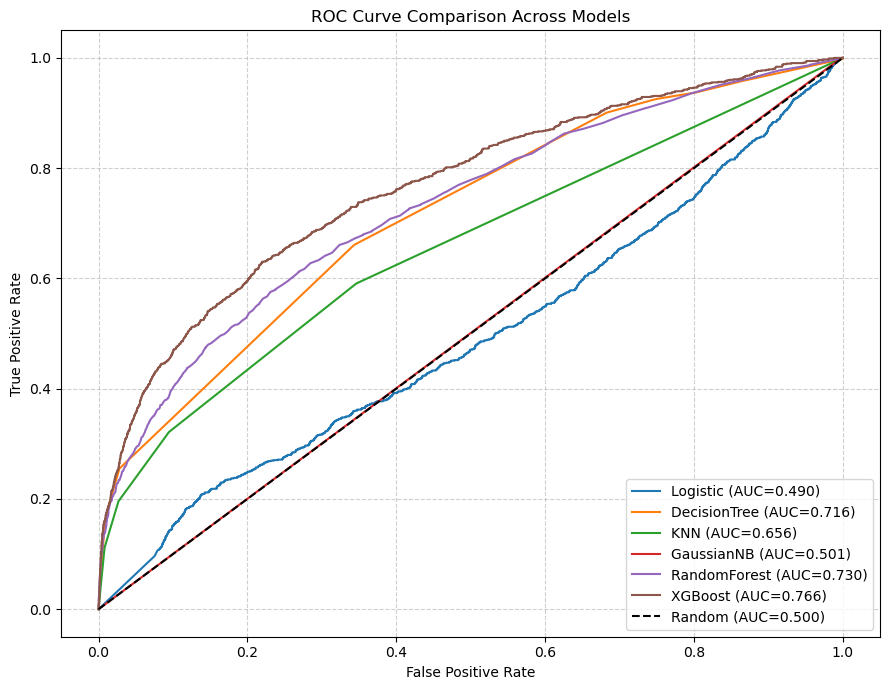

In [80]:
# ROC comparison
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

plt.figure(figsize=(9, 7))
#lr_proba  = model_LR.predict_proba(X_test)[:, 1]

# Recompute probas on TEST set ---
y_pred_probability   = model_LR.predict_proba(X_test)[:, 1]
dt_pred_proba        = dt_model.predict_proba(X_test)[:, 1]
knn_pred_probability = knn_model.predict_proba(X_test_scaled)[:, 1]
gnb_pred_proba       = gnb_model.predict_proba(X_test)[:, 1]
rf_pred_proba        = rf_model.predict_proba(X_test)[:, 1]
xgb_pred_proba       = hgb_model.predict_proba(X_test)[:, 1]  

for name, proba in {
    "Logistic": y_pred_probability,
    "DecisionTree": dt_pred_proba,
    "KNN": knn_pred_probability,
    "GaussianNB": gnb_pred_proba,
    "RandomForest": rf_pred_proba,
    "XGBoost": xgb_pred_proba
}.items():
    
    fpr, tpr, _ = roc_curve(Y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Models")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()




In [81]:
# Metrics Comparison
import pandas as pd

# Build summary table
summary = pd.DataFrame({
    "Classifier": [
        "Logistic Regression",
        "Decision Tree",
        "K-Nearest Neighbours",
        "Naive Bayes (Gaussian)",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":  [lr_acc, dt_accuracy, knn_accuracy, gnb_accuracy, rf_accuracy, hgb_accuracy],
    "Precision": [lr_precision, dt_precision, knn_precision, gnb_precision, rf_precision, hgb_precision],
    "Recall":    [lr_recall, dt_recall, knn_recall, gnb_recall, rf_recall, hgb_recall],
    "F1":        [lr_f1, dt_f1, knn_f1, gnb_f1, rf_f1, hgb_f1],
    "ROC":       [lr_auc, dt_auc, knn_auc, gnb_auc, rf_auc, hgb_auc],
    "MCC":       [lr_mcc, dt_mcc, knn_mcc, gnb_mcc, rf_mcc, hgb_mcc]
})

# Optional: round for display
summary_display = summary.copy()
for c in ["Accuracy","Precision","Recall","F1","ROC","MCC"]:
    summary_display[c] = summary_display[c].astype(float).round(2)

def highlight_max(s):
    is_max = s == s.max()
    return ["font-weight: bold" if v else "" for v in is_max]

summary_display = summary.copy().round(2)
# Styled table 
summary_display.style \
    .set_caption("Model Evaluation and Selection") \
    .apply(highlight_max, subset=["Accuracy","Precision","Recall","F1","ROC","MCC"]) \
    .set_table_styles([
        {"selector": "caption",
         "props": "caption-side: top; font-size: 22px; font-weight: 700; padding: 10px;"},
        {"selector": "th",
         "props": "background-color: #2F5597; color: white; font-weight: 700; text-align: center;"},
        {"selector": "td",
         "props": "text-align: center; padding: 8px;"},
        {"selector": "table",
         "props": "border-collapse: collapse; width: 100%;"},
        {"selector": "tbody tr:nth-child(even)",
         "props": "background-color: #F2F2F2;"},
        {"selector": "tbody tr:nth-child(odd)",
         "props": "background-color: #FFFFFF;"},
        {"selector": "td, th",
         "props": "border: 1px solid #D0D0D0;"}
    ]) \
    .hide(axis="index")



Classifier,Accuracy,Precision,Recall,F1,ROC,MCC
Logistic Regression,0.890000,0.650000,0.170000,0.270000,0.740000,0.300000
Decision Tree,0.890000,0.640000,0.190000,0.300000,0.720000,0.310000
K-Nearest Neighbours,0.880000,0.490000,0.200000,0.280000,0.660000,0.260000
Naive Bayes (Gaussian),0.790000,0.280000,0.480000,0.350000,0.730000,0.250000
Random Forest,0.890000,0.570000,0.210000,0.310000,0.730000,0.300000
XGBoost,0.890000,0.690000,0.170000,0.280000,0.770000,0.310000


In [82]:
import joblib

all_models = {
    "Logistic Regression": model_LR,
    "Decision Tree": dt_model,
    "KNN": knn_model,
    "Naive Bayes": gnb_model,
    "Random Forest": rf_model,
    "XGBoost": hgb_model
}

joblib.dump(all_models, "all_models.pkl")

['all_models.pkl']

In [83]:
feature_columns = list(X.columns)
joblib.dump(feature_columns, "feature_columns.pkl")
print("Saved feature_columns.pkl with", len(feature_columns), "features")

Saved feature_columns.pkl with 38 features


In [84]:
joblib.dump(scaler, "scaler.pkl")
print("Saved scaler.pkl successfully")

Saved scaler.pkl successfully


In [85]:
preprocess_meta = {
    "min_balance": float(min_balance)
}
joblib.dump(preprocess_meta, "preprocess_meta.pkl")
print("Saved preprocess_meta.pkl")

Saved preprocess_meta.pkl


In [86]:
joblib.dump(summary, "metrics_comparison.pkl")
print("Saved metrics_comparison.pkl")

Saved metrics_comparison.pkl
